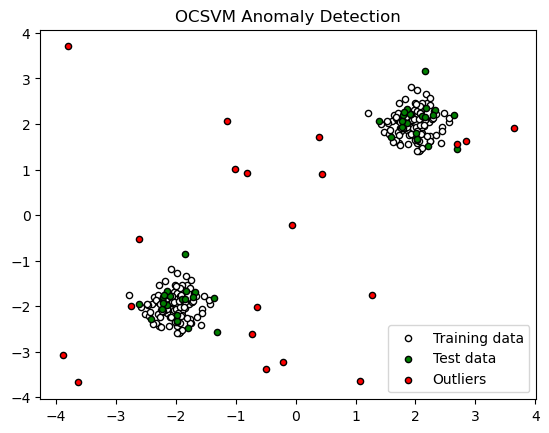

Accuracy: 0.8833333333333333
Precision: 0.7407407407407407
Recall: 1.0
F1-score: 0.851063829787234


In [19]:
import numpy as np
import pandas as pd
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 예시 데이터 생성 (2D)
np.random.seed(42)
X_train = 0.3 * np.random.randn(100, 2)  # 정상 데이터
X_train = np.r_[X_train + 2, X_train - 2]  # 데이터 분포 이동

X_test = 0.3 * np.random.randn(20, 2)  # 테스트용 정상 데이터
X_test = np.r_[X_test + 2, X_test - 2]

X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))  # 이상치 데이터

# OCSVM 모델 생성 및 학습
ocsvm = OneClassSVM(kernel="rbf", gamma=0.1, nu=0.1)  # RBF 커널 사용
ocsvm.fit(X_train)

# 예측 수행 (-1: 이상치, 1: 정상 데이터)
y_pred_train = ocsvm.predict(X_train)
y_pred_test = ocsvm.predict(X_test)
y_pred_outliers = ocsvm.predict(X_outliers)

# 시각화
plt.title("OCSVM Anomaly Detection")
plt.scatter(X_train[:, 0], X_train[:, 1], c='white', s=20, edgecolor='k', label='Training data')
plt.scatter(X_test[:, 0], X_test[:, 1], c='green', s=20, edgecolor='k', label='Test data')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', s=20, edgecolor='k', label='Outliers')
plt.legend()
plt.show()

# 실제 값 설정 (정상: 1, 이상치: -1)
y_true_test = np.ones(len(X_test))  # 정상 데이터는 1
y_true_outliers = -np.ones(len(X_outliers))  # 이상치는 -1

# 성능 평가 (F1-score, accuracy 등)
print("Accuracy:", accuracy_score(np.r_[y_true_test, y_true_outliers], np.r_[y_pred_test, y_pred_outliers]))
print("Precision:", precision_score(np.r_[y_true_test, y_true_outliers], np.r_[y_pred_test, y_pred_outliers], pos_label=-1))
print("Recall:", recall_score(np.r_[y_true_test, y_true_outliers], np.r_[y_pred_test, y_pred_outliers], pos_label=-1))
print("F1-score:", f1_score(np.r_[y_true_test, y_true_outliers], np.r_[y_pred_test, y_pred_outliers], pos_label=-1))

In [176]:
!pip install fastapi

   ---------------------------------------- 0.0/94.6 kB ? eta -:--:--
   ---------------------------------------- 94.6/94.6 kB 5.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/71.5 kB ? eta -:--:--
   ---------------------------------------- 71.5/71.5 kB ? eta 0:00:00


In [178]:
from fastapi import FastAPI

In [186]:
!pip install uvicorn

   ---------------------------------------- 0.0/62.8 kB ? eta -:--:--
   ---------------------------------------  61.4/62.8 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 62.8/62.8 kB 1.1 MB/s eta 0:00:00


In [181]:
app = FastAPI()

In [183]:
@app.get("/")
def root():
    return {"message" : "hello gdsc"}

@app.get("/home")
def home():
    return {"message" : "mlops study"}

In [58]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
import numpy as np
 
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_classification
 
## 실험용 데이터
X, _ = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.995, 0.005],
                           class_sep=0.5, random_state=100)

In [169]:
ocs = OneClassSVM(kernel='rbf', ## 커널 {‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}
          nu=0.05, ## Regularization Parameter
          gamma = 0.1 ## rbf의 감마
         ).fit(X)
outlier_labels = ocs.predict(X) ## -1 이상치, 1 정상 예측하기

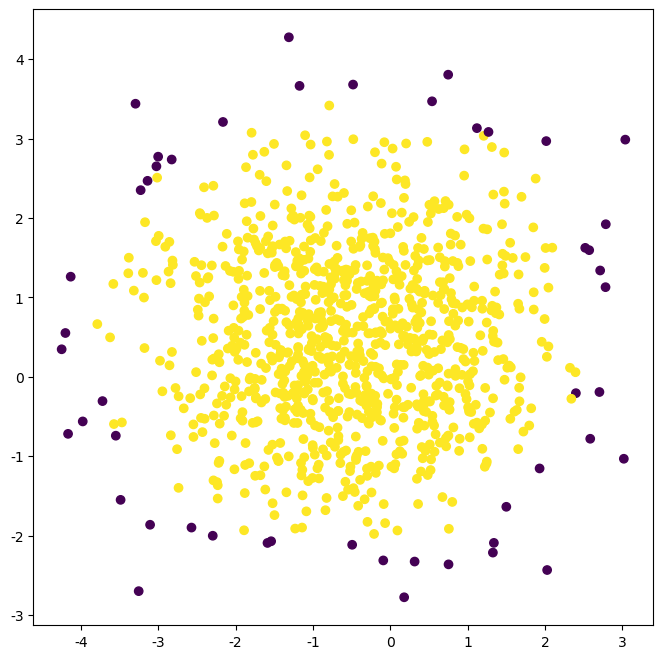

In [171]:
fig = plt.figure(figsize=(8, 8))
fig.set_facecolor('white')
ax = fig.add_subplot()
ax.scatter(X[:, 0], X[:, 1], c=outlier_labels)
plt.show()

In [147]:
## 스코어 기반 이상치 재 예측
score = ocs.score_samples(X)
score_threshold = np.percentile(score, 5) ## 하위 5프로
## 하위 5프로 이하인 경우는 모두 이상치로 예측한다.
new_labels = np.array([-1 if i < score_threshold else 1 for i in score])

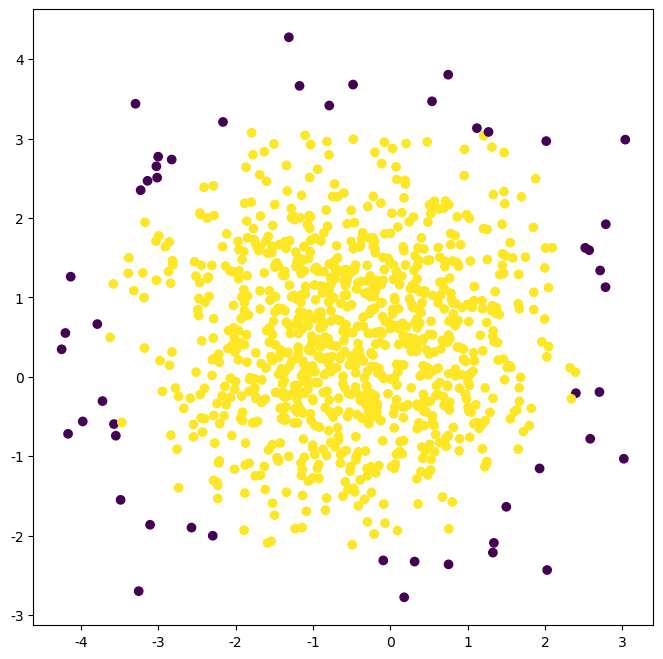

In [149]:
fig = plt.figure(figsize=(8, 8))
fig.set_facecolor('white')
ax = fig.add_subplot()
ax.scatter(X[:, 0], X[:, 1], c=new_labels)
plt.show()